In [5]:
import os
!pip install torch_geometric
import numpy as np
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm
from scipy.spatial import cKDTree

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.metrics import roc_auc_score
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from scipy.stats import wasserstein_distance

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
# ── Image → Point Cloud ────────────────────────────────────
def image_to_pointcloud(image, max_points=100):
    mask     = (image.sum(axis=0) > 0)
    eta, phi = np.where(mask)

    if len(eta) == 0:
        return np.zeros((1, 5), dtype=np.float32)

    ecal   = image[0, eta, phi]
    hcal   = image[1, eta, phi]
    tracks = image[2, eta, phi]
    energy = ecal + hcal + tracks

    if len(energy) > max_points:
        top_idx        = np.argsort(energy)[-max_points:]
        eta, phi       = eta[top_idx], phi[top_idx]
        ecal, hcal, tracks = ecal[top_idx], hcal[top_idx], tracks[top_idx]

    eta_n  = (eta / 124.0) * 2 - 1
    phi_n  = (phi / 124.0) * 2 - 1
    points = np.stack([eta_n, phi_n, ecal, hcal, tracks], axis=1)
    return points.astype(np.float32)

# ── Point Cloud → Graph ────────────────────────────────────
def build_graph(image, label, k=8, max_points=100):
    image = image.transpose(2, 0, 1).copy()
    for c in range(3):
        ch_max = image[c].max()
        if ch_max > 0:
            image[c] /= ch_max

    points = image_to_pointcloud(image, max_points)
    k_     = min(k, len(points) - 1)
    tree   = cKDTree(points[:, :2])
    _, idx = tree.query(points[:, :2], k=k_+1)
    idx    = idx[:, 1:]
    n      = len(points)
    row    = np.repeat(np.arange(n), k_)
    col    = idx.reshape(-1)
    edge_index = np.stack([row, col], axis=0).astype(np.int64)

    return Data(
        x          = torch.tensor(points,     dtype=torch.float32),
        edge_index = torch.tensor(edge_index, dtype=torch.long),
        y          = torch.tensor([label],    dtype=torch.long)
    )

print("Graph functions defined ✅")

Graph functions defined ✅


In [8]:
# ── Build Graph Dataset ────────────────────────────────────
print("Loading raw images into RAM...")
with h5py.File('/content/quark_gluon_data.h5', 'r') as f:
    X_raw = f['X_jets'][:20000]
    y_raw = f['y'][:20000]
print(f"Loaded: {X_raw.shape} ✅")

# ── Build all graphs ───────────────────────────────────────
print("Building graphs...")
graph_list = []
for i in tqdm(range(len(X_raw))):
    image = X_raw[i].transpose(2, 0, 1).copy()

    # Normalize
    for c in range(3):
        ch_max = image[c].max()
        if ch_max > 0:
            image[c] /= ch_max

    # Point cloud
    mask     = (image.sum(axis=0) > 0)
    eta, phi = np.where(mask)

    if len(eta) == 0:
        x          = np.zeros((1, 5), dtype=np.float32)
        edge_index = np.zeros((2, 0), dtype=np.int64)
    else:
        ecal   = image[0, eta, phi]
        hcal   = image[1, eta, phi]
        tracks = image[2, eta, phi]
        energy = ecal + hcal + tracks

        if len(energy) > 100:
            top_idx = np.argsort(energy)[-100:]
            eta, phi   = eta[top_idx], phi[top_idx]
            ecal, hcal, tracks = ecal[top_idx], hcal[top_idx], tracks[top_idx]

        eta_n = (eta / 124.0) * 2 - 1
        phi_n = (phi / 124.0) * 2 - 1
        x     = np.stack([eta_n, phi_n, ecal, hcal, tracks], axis=1).astype(np.float32)

        k_    = min(8, len(x) - 1)
        tree  = cKDTree(x[:, :2])
        _, idx = tree.query(x[:, :2], k=k_+1)
        idx   = idx[:, 1:]
        n     = len(x)
        row   = np.repeat(np.arange(n), k_)
        col   = idx.reshape(-1)
        edge_index = np.stack([row, col], axis=0).astype(np.int64)

    graph_list.append(Data(
        x          = torch.tensor(x,          dtype=torch.float32),
        edge_index = torch.tensor(edge_index, dtype=torch.long),
        y          = torch.tensor([int(y_raw[i])], dtype=torch.long)
    ))

print(f"Total graphs: {len(graph_list)} ✅")

Loading raw images into RAM...
Loaded: (20000, 125, 125, 3) ✅
Building graphs...


100%|██████████| 20000/20000 [00:16<00:00, 1214.93it/s]

Total graphs: 20000 ✅


In [9]:
# ── Split & Dataloaders ────────────────────────────────────
train_size = int(0.8 * len(graph_list))
val_size   = len(graph_list) - train_size

train_graphs = graph_list[:train_size]
val_graphs   = graph_list[train_size:]

train_loader = GeoDataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = GeoDataLoader(val_graphs,   batch_size=32, shuffle=False)

print(f"Train graphs : {len(train_graphs)}")
print(f"Val graphs   : {len(val_graphs)}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Train graphs : 16000
Val graphs   : 4000
Train batches: 500
Val batches  : 125


In [15]:
from torch_geometric.nn import EdgeConv, global_max_pool, global_mean_pool

# ── Graph Autoencoder ──────────────────────────────────────
class GraphEncoder(nn.Module):
    def __init__(self, in_channels=5, hidden=64, latent_dim=32):
        super().__init__()
        self.conv1 = EdgeConv(nn.Sequential(
            nn.Linear(in_channels * 2, hidden),
            nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden), nn.ReLU()
        ), aggr='max')
        self.conv2 = EdgeConv(nn.Sequential(
            nn.Linear(hidden * 2, hidden * 2),
            nn.BatchNorm1d(hidden * 2), nn.ReLU(),
            nn.Linear(hidden * 2, hidden * 2),
            nn.BatchNorm1d(hidden * 2), nn.ReLU()
        ), aggr='max')
        self.fc = nn.Linear(hidden * 2 * 2, latent_dim)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        # Global pooling
        x = torch.cat([global_mean_pool(x, batch),
                        global_max_pool(x, batch)], dim=1)
        return self.fc(x)

class GraphDecoder(nn.Module):
    def __init__(self, latent_dim=32, hidden=64, out_channels=5, num_points=100):
        super().__init__()
        self.num_points = num_points
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden * 2),
            nn.ReLU(),
            nn.Linear(hidden * 2, num_points * out_channels)
        )

    def forward(self, z):
        out = self.decoder(z)
        return out.view(z.size(0), self.num_points, -1)

class GraphAutoencoder(nn.Module):
    def __init__(self, in_channels=5, hidden=64, latent_dim=32, num_points=100):
        super().__init__()
        self.encoder = GraphEncoder(in_channels, hidden, latent_dim)
        self.decoder = GraphDecoder(latent_dim, hidden, in_channels, num_points)

    def forward(self, data):
        z    = self.encoder(data.x, data.edge_index, data.batch)
        recon = self.decoder(z)
        return recon, z

# ── Init ───────────────────────────────────────────────────
model     = GraphAutoencoder(in_channels=5, hidden=64, latent_dim=32, num_points=100).to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model initialized ✅")
print(f"Total parameters: {total_params:,}")

Model initialized ✅
Total parameters: 121,812


In [17]:
# ── Pad graphs to fixed size of 100 nodes ─────────────────
def pad_graph_nodes(data, max_nodes=100):
    """Pad or truncate node features to fixed size"""
    x = data.x
    n = x.shape[0]
    if n < max_nodes:
        pad = torch.zeros(max_nodes - n, x.shape[1])
        x   = torch.cat([x, pad], dim=0)
    else:
        x = x[:max_nodes]
    return x  # (100, 5)

# ── Loss Function ──────────────────────────────────────────
def graph_ae_loss(recon, data, max_nodes=100):
    """MSE only on valid (non-padded) nodes"""
    batch_size = recon.shape[0]
    targets    = []

    # Get per-graph node counts
    counts = torch.bincount(data.batch)

    start = 0
    for i, count in enumerate(counts):
        count  = count.item()
        nodes  = data.x[start:start+count]  # real nodes
        start += count

        # Pad to max_nodes
        if count < max_nodes:
            pad   = torch.zeros(max_nodes - count, nodes.shape[1]).to(nodes.device)
            nodes = torch.cat([nodes, pad], dim=0)
        else:
            nodes = nodes[:max_nodes]
        targets.append(nodes)

    targets = torch.stack(targets, dim=0)  # (B, 100, 5)
    return F.mse_loss(recon, targets), targets

print("Loss function defined ✅")

Loss function defined ✅


In [18]:
# ── Training Loop ──────────────────────────────────────────
EPOCHS = 30
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]")
    for batch in pbar:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, z     = model(batch)
        loss, _      = graph_ae_loss(recon, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss  += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # ── Validate ──
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val]  "):
            batch = batch.to(device)
            recon, z  = model(batch)
            loss, _   = graph_ae_loss(recon, batch)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/ml4sci-falcon/graph_ae_best.pth')

    print(f"✅ Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Best: {best_val_loss:.4f}\n")

print("Training complete ✅")

Epoch 01/30 [Val]  : 100%|██████████| 125/125 [00:00<00:00, 136.81it/s]


✅ Epoch 01 | Train: 0.0357 | Val: 0.0289 | Best: 0.0289



Epoch 02/30 [Val]  : 100%|██████████| 125/125 [00:00<00:00, 171.03it/s]


✅ Epoch 02 | Train: 0.0272 | Val: 0.0250 | Best: 0.0250



Epoch 03/30 [Val]  : 100%|██████████| 125/125 [00:00<00:00, 132.41it/s]


...

✅ Epoch 28 | Train: 0.0171 | Val: 0.0172 | Best: 0.0170



Epoch 29/30 [Val]  : 100%|██████████| 125/125 [00:00<00:00, 167.56it/s]


✅ Epoch 29 | Train: 0.0170 | Val: 0.0176 | Best: 0.0170



Epoch 30/30 [Val]  : 100%|██████████| 125/125 [00:00<00:00, 139.08it/s]

✅ Epoch 30 | Train: 0.0169 | Val: 0.0169 | Best: 0.0169

Training complete ✅


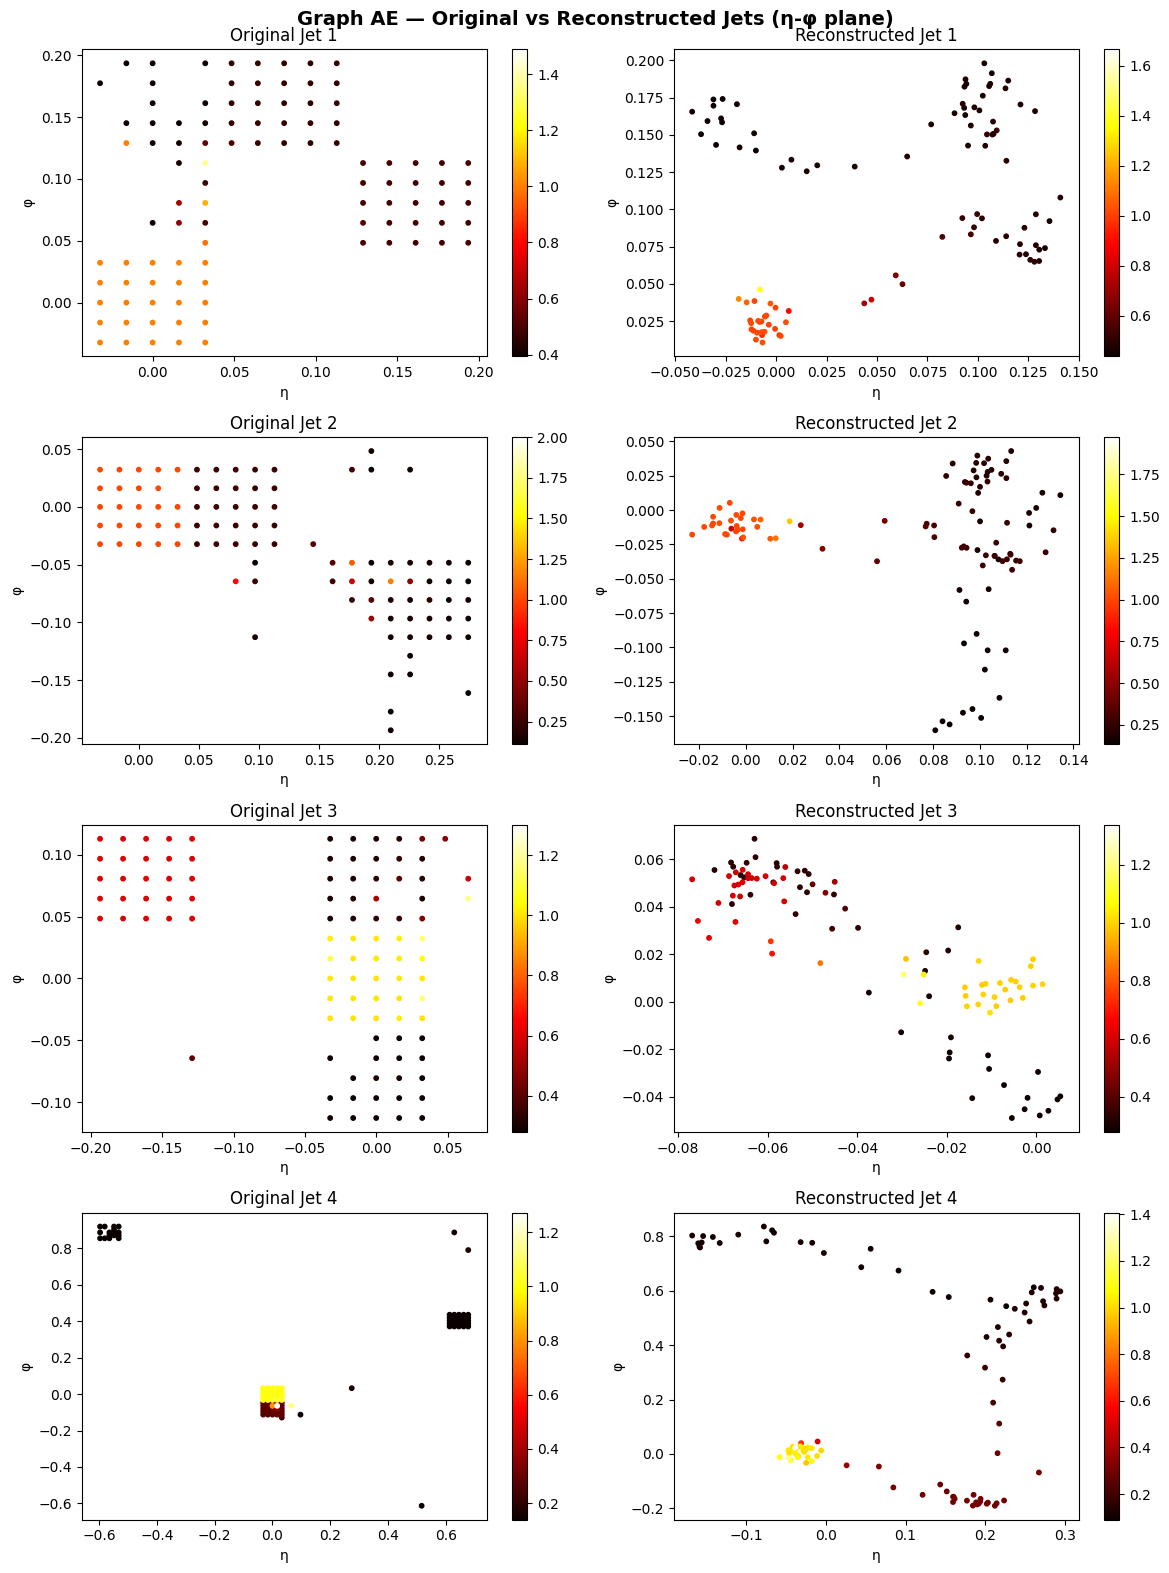

Saved ✅


In [19]:
# ── Load best model ────────────────────────────────────────
model.load_state_dict(torch.load('/content/drive/MyDrive/ml4sci-falcon/graph_ae_best.pth'))
model.eval()

# ── Get a batch ────────────────────────────────────────────
batch = next(iter(val_loader))
batch = batch.to(device)

with torch.no_grad():
    recon, z = model(batch)
    _, targets = graph_ae_loss(recon, batch)

recon   = recon.cpu().numpy()
targets = targets.cpu().numpy()

# ── Plot Original vs Reconstructed Point Clouds ────────────
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
fig.suptitle('Graph AE — Original vs Reconstructed Jets (η-φ plane)', fontsize=14, fontweight='bold')

for i in range(4):
    # Original
    orig  = targets[i]
    mask  = (orig.sum(axis=1) > 0)
    eta_o, phi_o   = orig[mask, 0], orig[mask, 1]
    energy_o       = orig[mask, 2] + orig[mask, 3] + orig[mask, 4]
    sc = axes[i, 0].scatter(eta_o, phi_o, c=energy_o, cmap='hot', s=10)
    axes[i, 0].set_title(f'Original Jet {i+1}')
    axes[i, 0].set_xlabel('η')
    axes[i, 0].set_ylabel('φ')
    plt.colorbar(sc, ax=axes[i, 0])

    # Reconstructed
    rec   = recon[i]
    mask  = (rec.sum(axis=1) > 0)
    eta_r, phi_r   = rec[mask, 0], rec[mask, 1]
    energy_r       = rec[mask, 2] + rec[mask, 3] + rec[mask, 4]
    sc = axes[i, 1].scatter(eta_r, phi_r, c=energy_r, cmap='hot', s=10)
    axes[i, 1].set_title(f'Reconstructed Jet {i+1}')
    axes[i, 1].set_xlabel('η')
    axes[i, 1].set_ylabel('φ')
    plt.colorbar(sc, ax=axes[i, 1])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml4sci-falcon/results/graph_ae_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

In [20]:
# ── Evaluation Metrics ─────────────────────────────────────
model.eval()
mse_scores, wass_scores = [], []
all_z, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        batch = batch.to(device)
        recon, z = model(batch)
        _, targets = graph_ae_loss(recon, batch)

        # MSE
        mse = F.mse_loss(recon, targets).item()
        mse_scores.append(mse)

        # Wasserstein distance on energy channel
        recon_np   = recon.cpu().numpy()
        target_np  = targets.cpu().numpy()
        for i in range(len(recon_np)):
            w = wasserstein_distance(
                target_np[i, :, 2],   # ECAL original
                recon_np[i, :, 2]     # ECAL reconstructed
            )
            wass_scores.append(w)

        all_z.append(z.cpu())
        all_labels.append(batch.y.view(-1).cpu())

all_z      = torch.cat(all_z).numpy()
all_labels = torch.cat(all_labels).numpy()

print(f"{'Metric':<20} {'Mean':>10} {'Std':>10}")
print(f"{'-'*42}")
print(f"{'MSE':<20} {np.mean(mse_scores):>10.6f} {np.std(mse_scores):>10.6f}")
print(f"{'Wasserstein':<20} {np.mean(wass_scores):>10.6f} {np.std(wass_scores):>10.6f}")

Evaluating: 100%|██████████| 125/125 [00:02<00:00, 49.97it/s]

Metric                     Mean        Std
------------------------------------------
MSE                    0.016870   0.002391
Wasserstein            0.028695   0.013902


Running t-SNE (takes ~1 min)...


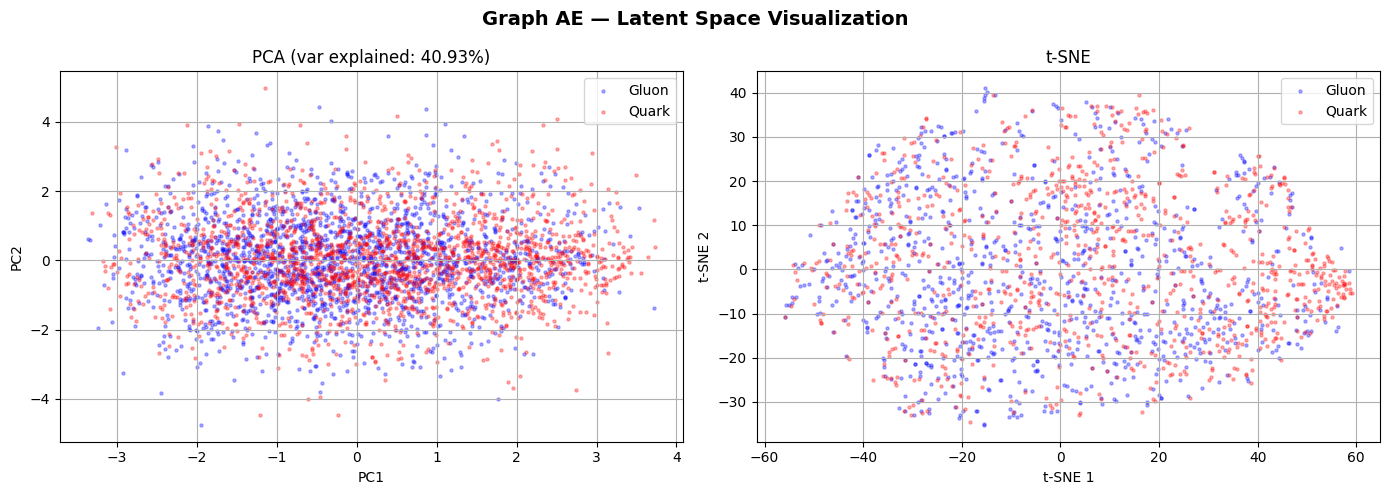

Saved ✅


In [21]:
# ── Latent Space Visualization ─────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph AE — Latent Space Visualization', fontsize=14, fontweight='bold')

colors = ['blue' if l == 0 else 'red' for l in all_labels]
labels_str = ['Gluon' if l == 0 else 'Quark' for l in all_labels]

# ── PCA ───────────────────────────────────────────────────
pca    = PCA(n_components=2)
z_pca  = pca.fit_transform(all_z)
axes[0].scatter(z_pca[all_labels==0, 0], z_pca[all_labels==0, 1],
                c='blue', alpha=0.3, s=5, label='Gluon')
axes[0].scatter(z_pca[all_labels==1, 0], z_pca[all_labels==1, 1],
                c='red',  alpha=0.3, s=5, label='Quark')
axes[0].set_title(f'PCA (var explained: {pca.explained_variance_ratio_.sum():.2%})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

# ── t-SNE ─────────────────────────────────────────────────
print("Running t-SNE (takes ~1 min)...")
tsne  = TSNE(n_components=2, perplexity=30, random_state=42)
z_tsne = tsne.fit_transform(all_z[:2000])  # subset for speed
axes[1].scatter(z_tsne[all_labels[:2000]==0, 0], z_tsne[all_labels[:2000]==0, 1],
                c='blue', alpha=0.3, s=5, label='Gluon')
axes[1].scatter(z_tsne[all_labels[:2000]==1, 0], z_tsne[all_labels[:2000]==1, 1],
                c='red',  alpha=0.3, s=5, label='Quark')
axes[1].set_title('t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml4sci-falcon/results/graph_ae_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")